In [1]:
%pip install diffinytrace.zip

Processing ./diffinytrace.zip
  Preparing metadata (setup.py) ... done
  Created wheel for diffinytrace: filename=diffinytrace-2.1-py3-none-any.whl size=93999 sha256=4ee5ba510d14783351cbd82f5b7a66098ff119e00a4f9c85085befd97a30b1e8
  Stored in directory: /tmp/pip-ephem-wheel-cache-apj_qdg7/wheels/70/69/4f/ea4fe5be2f8364573c110f26b2b32d6dd0dd84ab84341234f7
Successfully built diffinytrace
  Attempting uninstall: diffinytrace
    Found existing installation: diffinytrace 2.1
    Uninstalling diffinytrace-2.1:
      Successfully uninstalled diffinytrace-2.1


In [2]:
from google.colab import drive
drive.mount('/content/gdrive')
from os import listdir
from os.path import isfile, join
path = "gdrive/MyDrive/results_final"


Mounted at /content/gdrive


sigma refinment is using [34.26666666666666, 20.559999999999995, 11.42222222222222, 6.047058823529412, 3.1151515151515152, 1.5815384615384616, 0.7968992248062016, 0.4]
num of conv points should probably be at least  251.99999999999997


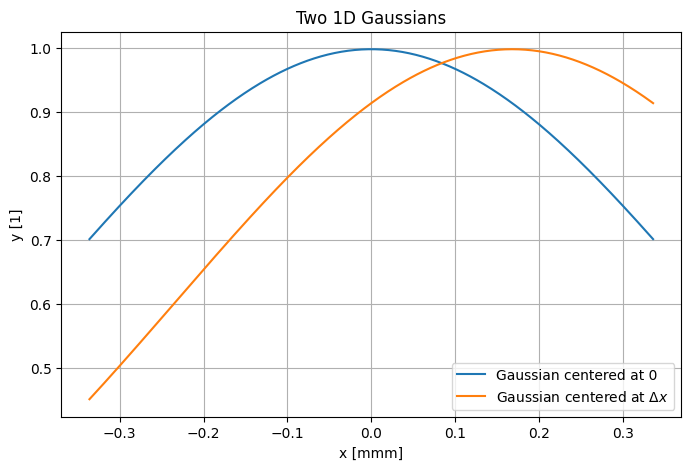

<Figure size 640x480 with 0 Axes>

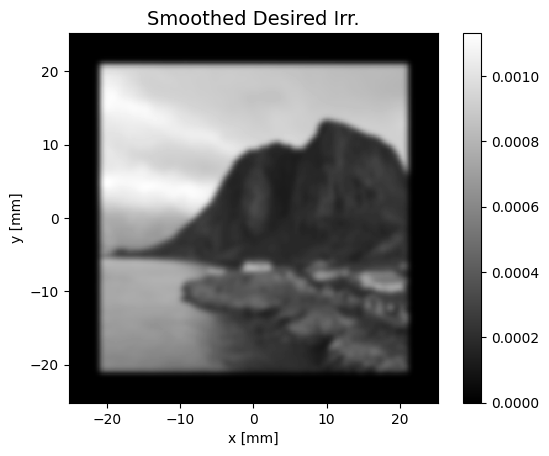

orders [3, 3]
ns [4, 4]
using sigmas [0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4]


/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


is valid all== tensor(True, device='cuda:0')
run_minimization_loop_classical
BEGIN: opti after refine: coeff shape: torch.Size([4, 4])
END
BEGIN: opti after refine: coeff shape: torch.Size([6, 6])
END
BEGIN: opti after refine: coeff shape: torch.Size([10, 10])
END
BEGIN: opti after refine: coeff shape: torch.Size([18, 18])
END
BEGIN: opti after refine: coeff shape: torch.Size([34, 34])
END
BEGIN: opti after refine: coeff shape: torch.Size([66, 66])
END
BEGIN: opti after refine: coeff shape: torch.Size([130, 130])
END
BEGIN: opti after refine: coeff shape: torch.Size([258, 258])
END
number of unset coefficients:  tensor(19040., device='cuda:0', dtype=torch.float32)
number of unset coefficients:  tensor(5282., device='cuda:0', dtype=torch.float32)
number of unset coefficients:  tensor(4986., device='cuda:0', dtype=torch.float32)
number of unset coefficients:  tensor(4692., device='cuda:0', dtype=torch.float32)
number of unset coefficients:  tensor(4400., device='cuda:0', dtype=torch.floa

In [3]:
#%%
import diffinytrace as dit
from diffinytrace.nonimaging.examples.sunlight_picture import create_lens
import os
import pickle
import gc

def save_data(data, filename):
    with open(filename, 'wb') as file:
        pickle.dump(data, file)
    print(f"Data saved to {filename}")

def load_data(filename):
    with open(filename, 'rb') as file:
        data = pickle.load(file)
    print(f"Data loaded from {filename}")
    return data

def create_folder(folder_path):
    try:
        os.makedirs(folder_path, exist_ok=True)
        return f"Folder created successfully at: {folder_path}" if not os.path.exists(folder_path) else f"Folder already exists at: {folder_path}"
    except Exception as e:
        return f"An error occurred: {e}"

device = "cuda:0"
image_file_name = "img1.jpg"
results_folder_main = path+"/results_NV1"
create_folder(results_folder_main)
sigma_final = 0.4

sigmas = None
ns_start = [4,4]
orders = [3,3]
num_refinements = 7

def get_all_sigmas_refined(_ns_start,_orders,_sigma_final,_num_refinements_plus):
    from diffinytrace import bspline_n_after_refinement
    n_current = _ns_start[0]
    order_k = _orders[0]
    all_n = [n_current]
    for k in range(_num_refinements_plus):
        n_current = bspline_n_after_refinement(n_current,order_k)
        all_n+=[n_current]


    sigma_current = _sigma_final

    all_sigma_rev = [sigma_current]
    for _k in range(_num_refinements_plus-1):
        k = _num_refinements_plus-_k
        ratio = ((all_n[k-1])/(all_n[k]))
        sigma_current = sigma_current*(1.0/ratio)
        all_sigma_rev += [sigma_current]

    all_sigma = all_sigma_rev[::-1]
    return all_sigma


sigmas = get_all_sigmas_refined(ns_start,orders,sigma_final,num_refinements+1)
print("sigma refinment is using",sigmas)
aperture_radius_source = 21.
image_padding = 0.2
num_conv_points = 300
num_rays = 2**19
num_integration_points_desired=[1601,1601]
from diffinytrace import utils
from diffinytrace.nonimaging import smoothing
aperture_radius_detector = aperture_radius_source*(1+image_padding)

print("num of conv points should probably be at least ", 2.0*aperture_radius_detector*2.0/sigma_final)
#%%
import numpy as np
import matplotlib.pyplot as plt

# Parameters
dx = (aperture_radius_detector*2.0)/num_conv_points
x = np.linspace(-dx*2, dx*2, 500)  # x-axis range

# Gaussian 1 centered at 0
gaussian1 = (1 / (sigma_final * np.sqrt(2 * np.pi))) * np.exp(-x**2 / (2 * sigma_final**2))

# Gaussian 2 centered at dx
gaussian2 = (1 / (sigma_final * np.sqrt(2 * np.pi))) * np.exp(-(x - dx)**2 / (2 * sigma_final**2))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, gaussian1, label='Gaussian centered at 0')
plt.plot(x, gaussian2, label=f'Gaussian centered at $\Delta x$')
plt.title("Two 1D Gaussians")
plt.xlabel("x [mmm]")
plt.ylabel("y [1]")
plt.legend()
plt.grid()
plt.show()


#%%
irr_func = utils.irradiance_importer.create_irradiance_from_image_square(image_file_name,image_padding,0.,aperture_radius_detector)

def create_smoother(sigma):
    return smoothing.GaussianSmootherSquare(aperture_radius= aperture_radius_detector,
                                                                       num_conv_points=num_conv_points,
                                                                        sigma=sigma,
                                                                        device=device,
                                                                        num_integration_points_desired=num_integration_points_desired,
                                                                        desired_irradiance_func=irr_func,
                                                                        residual_integration_method="midpoint",
                                                                        total_power_desired=1.0)

final_smoother = create_smoother(sigma_final)
from diffinytrace.plotting import quantity2D
quantity2D.plot(final_smoother.desired_smooth_irradiance.cpu().detach().numpy(),"Smoothed Desired Irr.",aperture_radius_detector,cmap="gray")
#plt.imshow(final_smoother.desired_smooth_irradiance.cpu().detach().numpy()[::-1])
#%%
def make_run(subfolder_main,use_sigma_refinement,use_desired_irradiance_smoothing,use_power_correction,etendue):
    create_folder(subfolder_main)
    subfolder = None
    if etendue:
        subfolder = subfolder_main+"/etendue"
    else:
        subfolder = subfolder_main+"/no_etendue"

    create_folder(subfolder)

    kwargs = dict(input_file_name=image_file_name,
                output_step_file_name=subfolder+"/lens.step",
                html_plot_file_name=subfolder+"/plot.html",
                lens_material=dit.materials["PMMA"],
                air_material=dit.materials["NONE"],
                device=device,
                num_refinements = num_refinements,
                sigma_final = sigma_final,
                num_conv_points = num_conv_points,
                num_integration_points_desired = num_integration_points_desired,
                image_padding=image_padding,
                etendue=etendue,
                use_sigma_refinement = use_sigma_refinement,
                use_desired_irradiance_smoothing = use_desired_irradiance_smoothing,
                use_power_correction = use_power_correction,
                save_history = True,
                save_irradiance_results=True,
                save_lens_history=True,
                num_rays=num_rays,
                bspline_ns_start = ns_start,
                num_rays_save_irradiance=2**19)

    results = create_lens(**kwargs)
    save_data(results, subfolder+"/results_dict.pkl")
    del results
    gc.collect()

#%%

#all_main_subfolders = ["results_classical","results_desired_irr_smoothing","results_power_correction_pure","results_power_correction_R"]

def run_all_methods(etendue):


    subfolder_main = results_folder_main+"/results_classical"
    make_run(subfolder_main,use_sigma_refinement = False,use_desired_irradiance_smoothing = False,use_power_correction=False,etendue=etendue)

    subfolder_main = results_folder_main+"/results_desired_irr_smoothing"
    make_run(subfolder_main,use_sigma_refinement = False,use_desired_irradiance_smoothing = True,use_power_correction=False,etendue=etendue)

    """
    subfolder_main = results_folder_main+"/results_sigma_refinement"
    make_run(subfolder_main,use_sigma_refinement = True,use_desired_irradiance_smoothing = True,use_power_correction=False,etendue=etendue)

    subfolder_main = results_folder_main+"/results_power_correction_pure"
    make_run(subfolder_main,use_sigma_refinement = False,use_desired_irradiance_smoothing = True,use_power_correction=True,etendue=etendue)

    subfolder_main = results_folder_main+"/results_power_correction_R"
    make_run(subfolder_main,use_sigma_refinement = True,use_desired_irradiance_smoothing = True,use_power_correction=True,etendue=etendue)
    """
run_all_methods(True)
run_all_methods(False)


In [4]:
#import os
#os.kill(os.getpid(), 9)